### Import Libraries

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os
from scipy import stats

#### Data Loading & Date Parsing

In [36]:
df = pd.read_csv("../data/ethiopia.csv")
print(df.shape)
display(df.head())

(4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


Add Country column

In [37]:
df["Country"] = "Ethiopia"

viewing the top rows of the data

In [38]:
display(df.head())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


Viewing the bottom rows of the dataset

In [39]:
display(df.tail())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia
4107,2026,90,18.25,26.36,12.14,14.22,0.40,63.95,2.18,3.64,76.47,10.14,Ethiopia


In [40]:
# added Country column
print(df.shape)
print(df.columns.tolist())

(4108, 13)
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country']


##### Convert YEAR and DOY to a single Datetime column
To convert the separate year and day columns into a single, usable date, we follow this process:

1.  **Mathematical Formula**: We combine the columns using $(YEAR \times 1000) + DOY$. 
    * *Example*: For the 14th day of 2015, the math is $(2015 \times 1000) + 14 = 2015014$.
2.  **Format Code (`%Y%j`)**:
    * `%Y`: Tells the computer the first 4 digits represent the **Year**.
    * `%j`: Tells the computer the remaining digits represent the **Day of the Year** (Julian day, 1-366).
3.  **Indexing**: By setting the `Date` as our index, we convert the DataFrame into a **Time Series object**. This makes filtering by year or plotting trends over time much more efficient.

In [41]:
# 3. Convert YEAR and DOY to a single Datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 4. Extract Month for seasonal analysis
# This allows us to group data by month (1=Jan, 12=Dec)
df["Month"] = df["Date"].dt.month

# 5. Set Date as the index
df.set_index("Date", inplace=True)

# Final check of the data structure
print(df.shape)
print(f"Dataset columns: {df.columns.tolist()}")
df.head()

(4108, 14)
Dataset columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Month']


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,1
2015-01-02,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,1
2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,1


Drop redundant columns after changing to datetime

In [31]:
df.drop(columns=["YEAR", "DOY"], inplace=True)

# Final check to see the clean dataset
print("Redundant columns removed.")
df.head()

Redundant columns removed.


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,1
2015-01-02,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,1
2015-01-03,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
2015-01-04,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
2015-01-05,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,1


In [16]:
print(df.index)

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2026-03-22', '2026-03-23', '2026-03-24', '2026-03-25',
               '2026-03-26', '2026-03-27', '2026-03-28', '2026-03-29',
               '2026-03-30', '2026-03-31'],
              dtype='datetime64[us]', name='Date', length=4108, freq=None)


In [17]:
display(df.loc['2015-01-01'])

YEAR               2015
DOY                   1
T2M               11.73
T2M_MAX           22.75
T2M_MIN            3.44
T2M_RANGE         19.31
PRECTOTCORR         0.0
RH2M              41.79
WS2M               2.73
WS2M_MAX           5.07
PS                77.13
QV2M                4.0
Country        Ethiopia
Month                 1
Name: 2015-01-01 00:00:00, dtype: object

### Summary Statistics & Missing-Value Report

In [42]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.DataFrame'>
DatetimeIndex: 4108 entries, 2015-01-01 to 2026-03-31
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
 12  Country      4108 non-null   str    
 13  Month        4108 non-null   int32  
dtypes: float64(10), int32(1), int64(2), str(1)
memory usage: 498.0 KB
None


A. Handling NASA Sentinel Values (-999) 

In [24]:
# Create a count of how many -999 values exist in each column
sentinel_counts = (df == -999).sum()

# Filter to show only columns that actually have -999 values
sentinel_counts = sentinel_counts[sentinel_counts > 0]

print("--- NASA Sentinel Value (-999) Report ---")
if not sentinel_counts.empty:
    print(sentinel_counts)
else:
    print("No -999 values found in the dataset.")

df.replace(-999, np.nan, inplace=True)

--- NASA Sentinel Value (-999) Report ---
No -999 values found in the dataset.


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,1
2015-01-02,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,1
2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,3
2026-03-28,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,3
2026-03-29,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,3


B. Duplicate Check

In [20]:
duplicates_count = df.duplicated().sum()

print(f"Total Duplicate Rows Found: {duplicates_count}")

# If duplicates exist, we drop them
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped successfully.")

Total Duplicate Rows Found: 0


C. Statistical Profiling
- Using df.describe() to get statistical summary of the numerical columns in a DataFrame

In [29]:
# Generate descriptive statistics for all numeric columns
print("summary statistics")
display(df.describe())

summary statistics


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,6.423564
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,3.477046
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,12.000000


Overview of categorical columns

In [33]:
print("The description of the categorical columns:")
print(df.describe(include=['object']))

The description of the categorical columns:
         Country
count       4108
unique         1
top     Ethiopia
freq        4108


C:\Users\sisay\AppData\Local\Temp\ipykernel_24448\2408349453.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['object']))


D. Missing Value Analysis (Null Percentage)

In [34]:
# Calculate total missing values per column
null_counts = df.isna().sum()

# Calculate the percentage of missing values
# Formula: (Missing / Total) * 100
total_rows = len(df)
null_percentages = (null_counts / total_rows) * 100

# Combine into a summary table
missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})

# Filter for columns with any missing values
missing_report = missing_report[missing_report['Missing Values'] > 0]

print("Missing Value Report")
display(missing_report)

# Flagging columns with >5% missing data
high_null_cols = null_percentages[null_percentages > 5].index.tolist()
if high_null_cols:
    print(f"WARNING: The following columns have >5% missing data: {high_null_cols}")
else:
    print("All columns have less than 5% missing data. The dataset is healthy.")

Missing Value Report


,Missing Values,Percentage (%)


All columns have less than 5% missing data. The dataset is healthy.


#### Outlier Detection & Basic Cleaning

In [43]:
cols_to_check = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [44]:
z_scores= np.abs(stats.zscore(df[cols_to_check]))

In [45]:
outlier_mask = (z_scores > 3).any(axis=1)
print(f"\nRows flagged as outliers: {outlier_mask.sum()}")


Rows flagged as outliers: 132


In [46]:
# Preview flagged rows
display(df[outlier_mask].head())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-05-25,2015,145,18.45,24.94,14.15,10.79,29.07,68.37,1.52,3.07,77.06,11.33,Ethiopia,5
2015-05-26,2015,146,17.60,23.52,13.22,10.30,34.38,75.91,1.66,3.53,77.07,11.89,Ethiopia,5
2015-06-27,2015,178,15.79,19.03,13.33,5.70,23.89,83.89,1.81,3.03,77.18,12.09,Ethiopia,6
2015-08-03,2015,215,15.97,21.06,12.58,8.48,23.46,84.73,1.58,2.55,77.04,12.32,Ethiopia,8
2016-07-10,2016,192,15.20,18.00,12.89,5.11,25.19,85.47,1.33,2.99,77.07,11.95,Ethiopia,7


##### Visualize outliers using a Box Plot

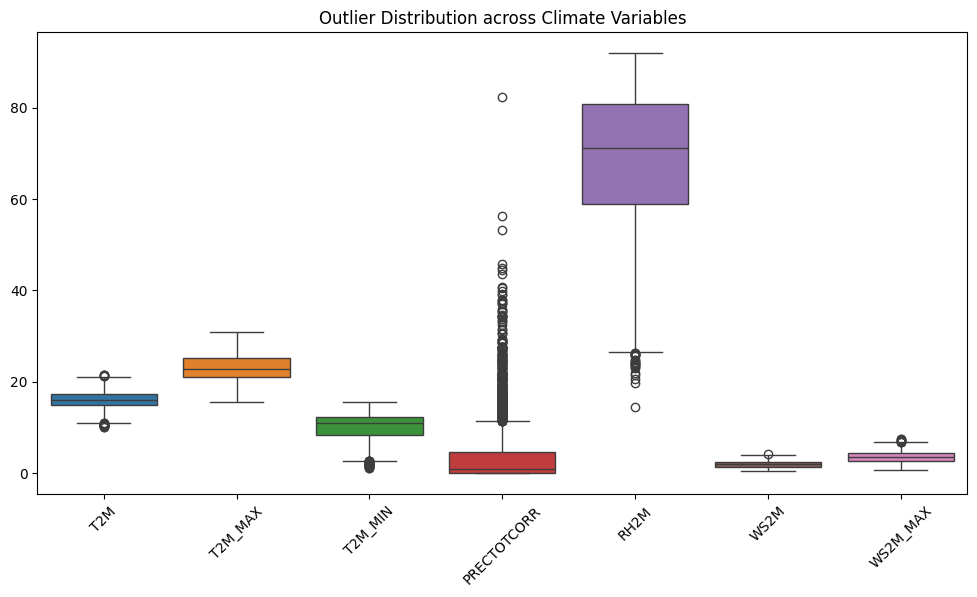

In [47]:
# Visualize outliers using a Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_check])
plt.title("Outlier Distribution across Climate Variables")
plt.xticks(rotation=45)
plt.show()

##### Outlier Handling Strategy
We identified 132 rows (~3.2% of the data) as statistical outliers ($|Z| > 3$). 

**Decision:** We will **retain** these outliers.

Reasoning:
* Climate Signal: In Ethiopia, extreme rainfall events or heatwaves are not "errors"—they are critical data points for climate change analysis.
* Integrity: Dropping 3% of the most extreme days would artificially "smooth" our data, making the climate look more stable than it actually is.
* Physical Bound Check: A quick review shows no impossible values (e.g., temperatures > $50^\circ C$ or Relative Humidity > $100\%$).

Identify and drop rows that are mostly empty

In [56]:
missing_threshold = 0.3
mask_extreme_missing = df.isnull().mean(axis=1) > missing_threshold
df_cleaned = df[~mask_extreme_missing].copy()

In [57]:
# 2. Apply Forward Fill (ffill) to handle the remaining small gaps
# This propagates the last valid observation to the next valid one
df_cleaned.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,1
2015-01-02,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,1
2015-01-03,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,1
2015-01-04,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,1
2015-01-05,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,3
2026-03-28,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,3
2026-03-29,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,3


In [58]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print(f"Total nulls remaining: {df_cleaned.isna().sum().sum()}")

Original shape: (4108, 14)
Cleaned shape: (4108, 14)
Total nulls remaining: 0


In [60]:
output_path = "../data/ethiopia_clean.csv"
df_cleaned.to_csv(output_path)

print(f"Success! Cleaned data exported to: {output_path}")

Success! Cleaned data exported to: ../data/ethiopia_clean.csv
